## Feature Engineering

### Creating new analytical features from existing columns.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../Dataset/blinkit_cleaned_dataset.csv')

df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [6]:
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

df[['Outlet_Establishment_Year','Outlet_Age']].head()

,Outlet_Establishment_Year,Outlet_Age
0,1999,27
1,2009,17
2,1999,27
3,1998,28
4,1987,39


## Outlet Age Analysis

### Checking whether outlet age influences sales performance.

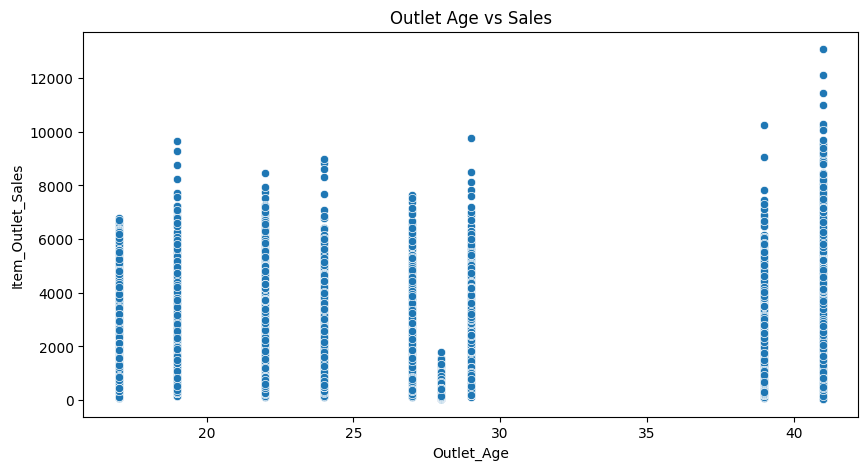

In [8]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    x='Outlet_Age',
    y='Item_Outlet_Sales',
    data=df
)

plt.title('Outlet Age vs Sales')

plt.show()

### Insight

- Older outlets show slightly stronger sales performance.
- The relationship is not very strong.
- Outlet age alone does not determine sales.
- Multiple business factors likely influence outlet performance.

## Price Category Feature

### Creating product price groups based on Item MRP.

In [9]:
df['Price_Category'] = pd.cut(
    df['Item_MRP'],
    bins=[0, 100, 200, 300],
    labels=['Low', 'Medium', 'High']
)
df[['Item_MRP','Price_Category']].head()

,Item_MRP,Price_Category
0,249.8092,High
1,48.2692,Low
2,141.6180,Medium
3,182.0950,Medium
4,53.8614,Low


## Sales by Price Category

### Understanding sales performance across different price ranges.

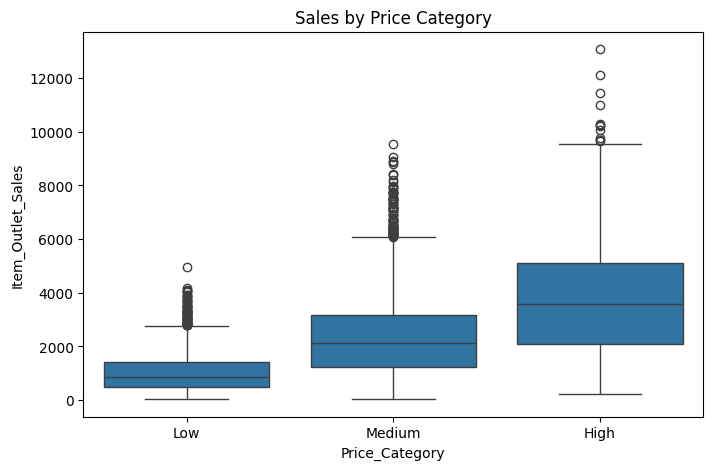

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Price_Category',
    y='Item_Outlet_Sales',
    data = df
)

plt.title('Sales by Price Category')
plt.show()

## Product Category Feature

### Creating a broad category from Item Identifier.

In [13]:
df['Product_Category'] = df['Item_Identifier'].str[:2]

df['Product_Category'] = df['Product_Category'].replace({
    'FD':'Food',
    'DR':'Drinks',
    'NC':'Non-Consumable'
})

df[['Item_Identifier','Product_Category']].head()

,Item_Identifier,Product_Category
0,FDA15,Food
1,DRC01,Drinks
2,FDN15,Food
3,FDX07,Food
4,NCD19,Non-Consumable


## Sales by Product Category

### Understanding sales performance across broad product categories.

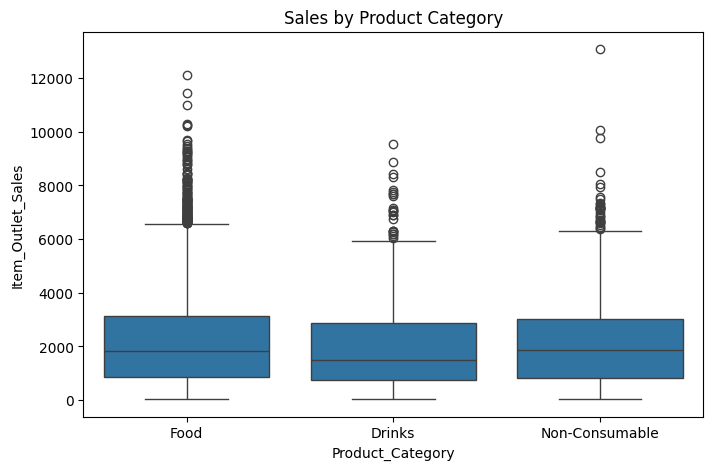

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Product_Category',
    y='Item_Outlet_Sales',
    data=df
)

plt.title('Sales by Product Category')
plt.show()

### Insight

- Non-Consumable products show slightly higher sales performance.
- Food products also perform strongly.
- Drinks show comparatively lower sales values.
- Product category has a moderate influence on sales.

## Outlet Size Encoding

### Converting outlet size categories into numerical values.

In [17]:
df['Outlet_Size_Code'] = df['Outlet_Size'].map({
    'Small':1,
    'Medium':2,
    'High':3
})

df[['Outlet_Size','Outlet_Size_Code']].head()

,Outlet_Size,Outlet_Size_Code
0,2,NaN
1,2,NaN
2,2,NaN
3,2,NaN
4,3,NaN


## Sales by Outlet Size Code

### Understanding how outlet size influences sales.

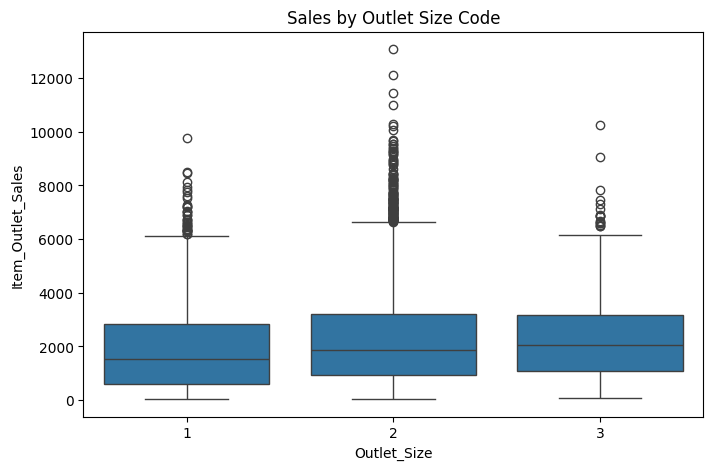

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Outlet_Size',
    y='Item_Outlet_Sales',
    data=df
)

plt.title('Sales by Outlet Size Code')

plt.show()

## Visibility Category Feature

### Grouping products based on visibility levels.

In [21]:
df['Visibility_Category'] = pd.cut(
    df['Item_Visibility'],
    bins=[-0.01,0.05,0.15,0.35],
    labels=['Low','Medium','High']
)

df[['Item_Visibility','Visibility_Category']].head()

,Item_Visibility,Visibility_Category
0,0.016047,Low
1,0.019278,Low
2,0.016760,Low
3,0.000000,Low
4,0.000000,Low


## Sales by Visibility Category

### Understanding whether product visibility influences sales performance.

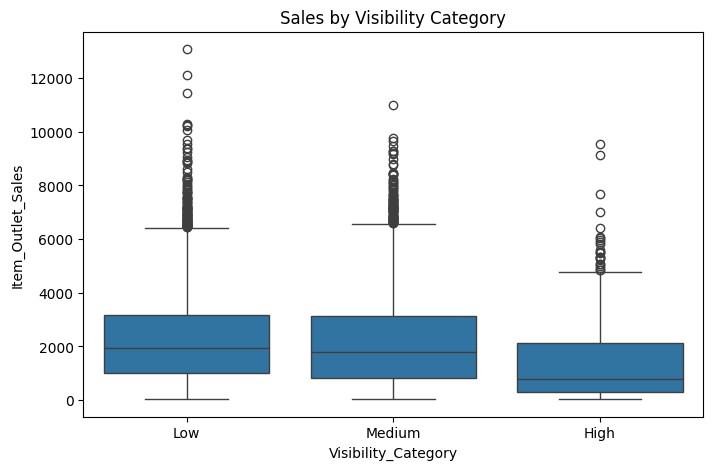

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Visibility_Category',
    y='Item_Outlet_Sales',
    data = df
)

plt.title('Sales by Visibility Category')
plt.show()

## Fat Content Encoding

### Converting fat content categories into numerical values.

In [23]:
df['Fat_Content_Code'] = df['Item_Fat_Content'].map({
    'Low Fat':0,
    'Regular':1
})

df[['Item_Fat_Content','Fat_Content_Code']].head()

,Item_Fat_Content,Fat_Content_Code
0,Low Fat,0
1,Regular,1
2,Low Fat,0
3,Regular,1
4,Low Fat,0


## Sales by Fat Content

### Understanding whether product fat content influences sales.

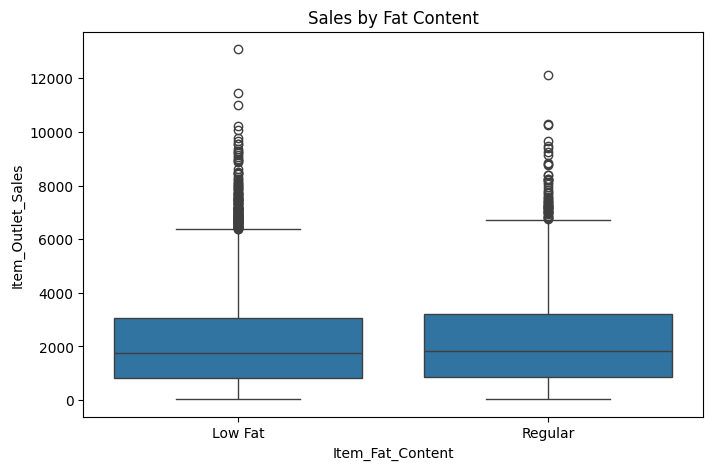

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Item_Fat_Content',
    y='Item_Outlet_Sales',
    data=df
)

plt.title('Sales by Fat Content')
plt.show()